In [7]:
#Importing the Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn


In [8]:
#Reading customer dataset
customers = pd.read_csv('C:/Users/sumay/OneDrive/Desktop/EDA_Sales_Customer/customer_data.csv.zip', compression='zip')
customers.info()
customers.describe()
print(customers.head())

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     99457 non-null  str    
 1   gender          99457 non-null  str    
 2   age             99338 non-null  float64
 3   payment_method  99457 non-null  str    
dtypes: float64(1), str(3)
memory usage: 3.0 MB
  customer_id  gender   age payment_method
0     C241288  Female  28.0    Credit Card
1     C111565    Male  21.0     Debit Card
2     C266599    Male  20.0           Cash
3     C988172  Female  66.0    Credit Card
4     C189076  Female  53.0           Cash


In [9]:
##Checking Null values in customer data

print(customers.isnull().sum())

customer_id         0
gender              0
age               119
payment_method      0
dtype: int64


In [10]:
#Handling the null values in age column

customers['age'] = customers['age'].fillna(customers['age'].median())
print(customers.isnull().sum())

customer_id       0
gender            0
age               0
payment_method    0
dtype: int64


In [11]:
#Checking the duplicates in customer data


customers_duplicates = customers.duplicated().sum()
print(customers_duplicates)

0


In [12]:
#Sales dataset

sales = pd.read_csv('C:/Users/sumay/OneDrive/Desktop/EDA_Sales_Customer/sales_data.csv.zip', compression='zip')
sales.info()
sales.describe()
print(sales.head())

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   invoice_no     99457 non-null  str    
 1   customer_id    99457 non-null  str    
 2   category       99457 non-null  str    
 3   quantity       99457 non-null  int64  
 4   price          99457 non-null  float64
 5   invoice_date   99457 non-null  str    
 6   shopping_mall  99457 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 5.3 MB
  invoice_no customer_id  category  quantity    price invoice_date  \
0    I138884     C241288  Clothing         5  1500.40   05-08-2022   
1    I317333     C111565     Shoes         3  1800.51   12-12-2021   
2    I127801     C266599  Clothing         1   300.08   09-11-2021   
3    I173702     C988172     Shoes         5  3000.85   16-05-2021   
4    I337046     C189076     Books         4    60.60   24-10-2021   

    shopping_mall  
0       

In [13]:
#Inspecting dataset

sales.info()
sales.describe()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   invoice_no     99457 non-null  str    
 1   customer_id    99457 non-null  str    
 2   category       99457 non-null  str    
 3   quantity       99457 non-null  int64  
 4   price          99457 non-null  float64
 5   invoice_date   99457 non-null  str    
 6   shopping_mall  99457 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 5.3 MB


,quantity,price
count,99457.000000,99457.000000
mean,3.003429,689.256321
std,1.413025,941.184567
min,1.000000,5.230000
25%,2.000000,45.450000
50%,3.000000,203.300000
75%,4.000000,1200.320000
max,5.000000,5250.000000


In [14]:
#Checking null values

sales.isnull().sum()

invoice_no       0
customer_id      0
category         0
quantity         0
price            0
invoice_date     0
shopping_mall    0
dtype: int64

In [15]:
#Checking the duplicates in sales Data

sales_duplicates = sales.duplicated().sum()
print(sales_duplicates)

0


In [16]:
# Merging two dataset

customers_sales = customers.merge(sales, on = 'customer_id', how='inner')
customers_sales

,customer_id,gender,age,payment_method,invoice_no,category,quantity,price,invoice_date,shopping_mall
0,C241288,Female,28.0,Credit Card,I138884,Clothing,5,1500.40,05-08-2022,Kanyon
1,C111565,Male,21.0,Debit Card,I317333,Shoes,3,1800.51,12-12-2021,Forum Istanbul
2,C266599,Male,20.0,Cash,I127801,Clothing,1,300.08,09-11-2021,Metrocity
3,C988172,Female,66.0,Credit Card,I173702,Shoes,5,3000.85,16-05-2021,Metropol AVM
4,C189076,Female,53.0,Cash,I337046,Books,4,60.60,24-10-2021,Kanyon
...,...,...,...,...,...,...,...,...,...,...
99452,C441542,Female,45.0,Credit Card,I219422,Souvenir,5,58.65,21-09-2022,Kanyon
99453,C569580,Male,27.0,Cash,I325143,Food & Beverage,2,10.46,22-09-2021,Forum Istanbul
99454,C103292,Male,63.0,Debit Card,I824010,Food & Beverage,2,10.46,28-03-2021,Metrocity
99455,C800631,Male,56.0,Cash,I702964,Technology,4,4200.00,16-03-2021,Istinye Park


<Axes: xlabel='age', ylabel='Count'>

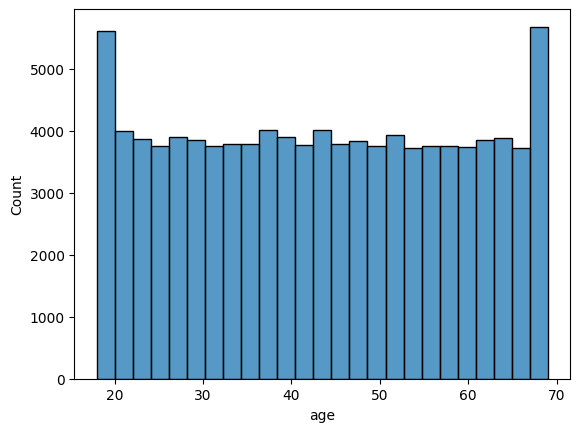

In [17]:
#Age distribution ---->visuals

seaborn.histplot(customers_sales['age'], bins=25)


<Axes: xlabel='age group', ylabel='total_revenue'>

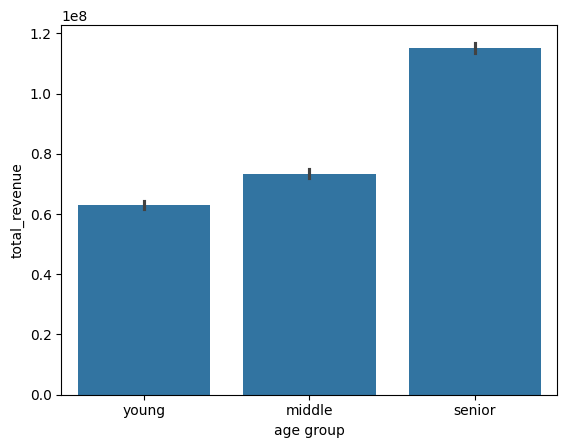

In [25]:
#Age distribution ---> which group has spent more

seaborn.barplot(customers_sales, x = 'age group', y = 'total_revenue', estimator=sum)

In [23]:
# Age Analysis - Min spent age group. ---> INSIGHTS
customers_sales['age group'] = pd.cut(customers_sales['age'], bins=[0,30,45,120], labels=['young', 'middle', 'senior'])

customers_sales['total_revenue'] = customers_sales['price'] * customers_sales['quantity']
min_revenue_by_agegroup = customers_sales.groupby('age group')['total_revenue'].sum()
min_revenue_by_agegroup.idxmin()

'young'

In [24]:
#Age Analysis = max spent age group. ----> INSIGHTS

customers_sales['age group'] = pd.cut(customers_sales['age'], bins=[0,30,45,120], labels=['young', 'middle', 'senior'])
max_revenue_by_agegroup = customers_sales.groupby('age group')['total_revenue'].sum()
max_revenue_by_agegroup.idxmax()

'senior'